# CVE Risk Classification — 04: PyTorch Neural Network
**Imperial Business School Capstone | MSc Cybersecurity + AI/ML**

**Purpose:** Deep learning layer for severity classification using CVE
description text. Complements the hybrid KNN + Decision Tree (notebook 03)
by capturing semantic relationships in unstructured text.

## Design decisions (vs earlier exploratory version)
- Vocabulary capped at **10,000** most frequent tokens (was ~76k → overfitting)
- Minimum token frequency: **5** occurrences
- **20 epochs** with early stopping (was 3)
- Learning rate scheduler (CosineAnnealingLR)
- `class_weight` tensor for imbalanced classes
- Proper train/val/test split — **no leakage**

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, re
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

df = pd.read_csv('data/df_clean.csv')
# ── Merge LOW → MEDIUM (consistent with notebook 03)
# Operationally equivalent severity tier — see methodology Section 3
df['base_severity'] = df['base_severity'].replace('LOW', 'MEDIUM')

print('Class distribution after LOW → MEDIUM merge:')
print(df['base_severity'].value_counts())

print(f'Loaded: {df.shape}')

Device: cpu
Class distribution after LOW → MEDIUM merge:
base_severity
MEDIUM      70019
HIGH        61680
CRITICAL    24153
Name: count, dtype: int64
Loaded: (155852, 22)


## 1. Text Preprocessing & Vocabulary

In [10]:
# ── Cybersecurity stop words (domain-specific)
CYBER_NOISE = {
    'vulnerability','attacker','allows','versions','issue','could','via',
    'has','access','arbitrary','remote','been','may','affected','are',
    'through','all','attackers','prior','when','into','used','user','was',
    'not','allow','execute','execution','this','can','from','before','which'
}

def tokenise(text):
    if pd.isna(text): return []
    text = re.sub(r'[^\w\s]', ' ', str(text).lower())
    return [w for w in text.split()
            if w not in CYBER_NOISE and len(w) > 2]

# ── Build vocabulary on TRAINING data only (split first)
le_target = LabelEncoder()
y = le_target.fit_transform(df['base_severity'])
texts = df['description_data'].fillna('').values

# 60% train, 20% val, 20% test
X_tr, X_tmp, y_tr, y_tmp = train_test_split(texts, y, test_size=0.4,
                                              random_state=42, stratify=y)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5,
                                              random_state=42, stratify=y_tmp)

# Vocabulary from TRAINING set only (no leakage)
MIN_FREQ = 5
MAX_VOCAB = 10_000

all_tokens = []
for t in X_tr:
    all_tokens.extend(tokenise(t))

token_counts = Counter(all_tokens)
vocab_tokens = [tok for tok, cnt in token_counts.most_common(MAX_VOCAB)
                if cnt >= MIN_FREQ]

vocab = {'<PAD>': 0, '<UNK>': 1}
for tok in vocab_tokens:
    vocab[tok] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f'Vocabulary size: {VOCAB_SIZE:,} (was ~76k in exploratory version)')
print(f'Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_te)}')

Vocabulary size: 10,002 (was ~76k in exploratory version)
Train: 93511 | Val: 31170 | Test: 31171


## 2. Dataset & DataLoader

In [11]:
MAX_LEN = 128  # CVE descriptions are rarely longer

def encode(text, vocab, max_len=MAX_LEN):
    tokens = tokenise(text)
    ids = [vocab.get(t, vocab['<UNK>']) for t in tokens][:max_len]
    ids += [vocab['<PAD>']] * (max_len - len(ids))
    return ids

class CVEDataset(Dataset):
    def __init__(self, texts, labels):
        self.X = [encode(t, vocab) for t in texts]
        self.y = labels
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return (torch.tensor(self.X[i], dtype=torch.long),
                torch.tensor(self.y[i],  dtype=torch.long))

BATCH = 128
train_loader = DataLoader(CVEDataset(X_tr, y_tr),  batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(CVEDataset(X_val, y_val), batch_size=BATCH)
test_loader  = DataLoader(CVEDataset(X_te, y_te),   batch_size=BATCH)
print('DataLoaders ready ✓')

DataLoaders ready ✓


## 3. Model Architecture

In [12]:
class CVEClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, n_classes=4, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout   = nn.Dropout(dropout)
        self.fc1       = nn.Linear(embed_dim, hidden_dim)
        self.relu      = nn.ReLU()
        self.fc2       = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        # Mean pooling over sequence (simple but effective for classification)
        emb  = self.embedding(x)          # (batch, seq_len, embed_dim)
        mask = (x != 0).float().unsqueeze(-1)  # ignore PAD tokens
        emb  = (emb * mask).sum(1) / mask.sum(1).clamp(min=1)
        out  = self.dropout(emb)
        out  = self.relu(self.fc1(out))
        out  = self.dropout(out)
        return self.fc2(out)

N_CLASSES = len(le_target.classes_)
model = CVEClassifier(VOCAB_SIZE, n_classes=N_CLASSES).to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

CVEClassifier(
  (embedding): Embedding(10002, 64, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)
Parameters: 648,835


## 4. Training with Class Weights & Early Stopping

In [13]:
# ── Class weights to address imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weight_tensor)

optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler  = CosineAnnealingLR(optimizer, T_max=20)

EPOCHS    = 20
PATIENCE  = 4   # early stopping patience

train_losses, val_losses, val_accs = [], [], []
best_val_acc = 0
patience_count = 0

for epoch in range(1, EPOCHS + 1):
    # ── Training
    model.train()
    running_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()

    # ── Validation
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            val_loss += criterion(logits, yb).item()
            correct  += (logits.argmax(1) == yb).sum().item()
            total    += len(yb)

    val_acc = correct / total
    train_losses.append(running_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_acc)

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {train_losses[-1]:.4f} | '
          f'Val Loss: {val_losses[-1]:.4f} | '
          f'Val Acc: {val_acc:.4f}')

    # ── Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'models/pytorch_best.pt')
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch 01/20 | Train Loss: 0.8858 | Val Loss: 0.7581 | Val Acc: 0.6329
Epoch 02/20 | Train Loss: 0.7649 | Val Loss: 0.7111 | Val Acc: 0.6641
Epoch 03/20 | Train Loss: 0.7187 | Val Loss: 0.6841 | Val Acc: 0.6814
Epoch 04/20 | Train Loss: 0.6933 | Val Loss: 0.6684 | Val Acc: 0.6877
Epoch 05/20 | Train Loss: 0.6700 | Val Loss: 0.6586 | Val Acc: 0.6907
Epoch 06/20 | Train Loss: 0.6540 | Val Loss: 0.6495 | Val Acc: 0.6967
Epoch 07/20 | Train Loss: 0.6428 | Val Loss: 0.6442 | Val Acc: 0.7033
Epoch 08/20 | Train Loss: 0.6307 | Val Loss: 0.6408 | Val Acc: 0.7079
Epoch 09/20 | Train Loss: 0.6225 | Val Loss: 0.6368 | Val Acc: 0.7074
Epoch 10/20 | Train Loss: 0.6154 | Val Loss: 0.6354 | Val Acc: 0.7116
Epoch 11/20 | Train Loss: 0.6089 | Val Loss: 0.6331 | Val Acc: 0.7118
Epoch 12/20 | Train Loss: 0.6038 | Val Loss: 0.6329 | Val Acc: 0.7129
Epoch 13/20 | Train Loss: 0.5988 | Val Loss: 0.6312 | Val Acc: 0.7112
Epoch 14/20 | Train Loss: 0.5965 | Val Loss: 0.6306 | Val Acc: 0.7130
Epoch 15/20 | Train 

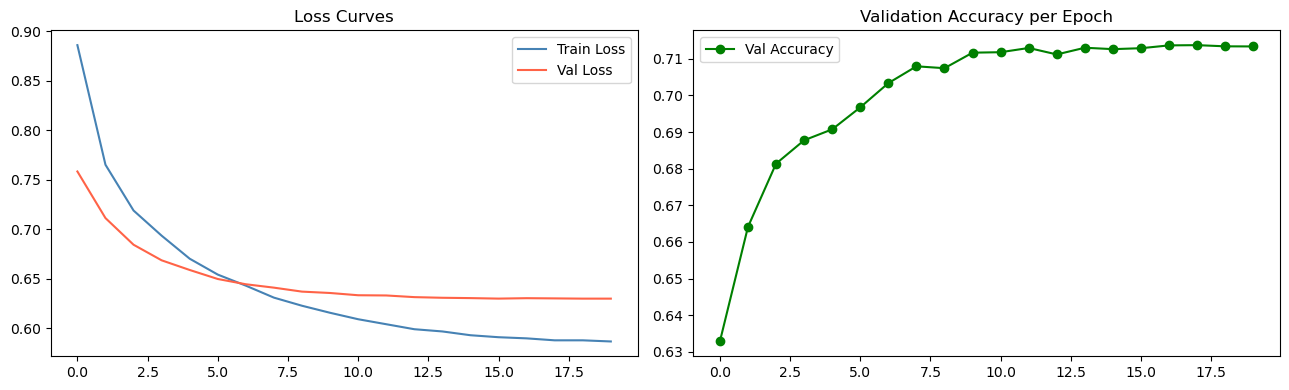

In [14]:
# ── Learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses,   label='Val Loss',   color='tomato')
axes[0].set_title('Loss Curves')
axes[0].legend()

axes[1].plot(val_accs, label='Val Accuracy', color='green', marker='o')
axes[1].set_title('Validation Accuracy per Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/04_learning_curves.png', dpi=150)
plt.show()

## 5. Test Set Evaluation

In [15]:
# ── Load best checkpoint
model.load_state_dict(torch.load('models/pytorch_best.pt', map_location=device))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

print('=== PYTORCH MODEL — TEST SET RESULTS ===')
print(f'Accuracy: {accuracy_score(all_true, all_preds):.4f}')
print()
print(classification_report(all_true, all_preds, target_names=le_target.classes_))

=== PYTORCH MODEL — TEST SET RESULTS ===
Accuracy: 0.7162

              precision    recall  f1-score   support

    CRITICAL       0.51      0.79      0.62      4831
        HIGH       0.71      0.62      0.66     12336
      MEDIUM       0.84      0.78      0.81     14004

    accuracy                           0.72     31171
   macro avg       0.69      0.73      0.70     31171
weighted avg       0.74      0.72      0.72     31171

